In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, RocCurveDisplay)
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv")
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
def preprocess_data(df):
    # 处理分类变量（示例）
    df = pd.get_dummies(df, columns=['person_education', 'person_home_ownership', 'loan_intent'])
    df['person_gender'] = df['person_gender'].map({'male':0, 'female':1})
    df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No':0, 'Yes':1})
    return df

In [6]:
df_clean = preprocess_data(df)

In [7]:
# 划分数据集
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# 创建处理管道
lr_pipe = Pipeline([
    ('scaler', StandardScaler()), # 标准化处理
    ('lr', LogisticRegression(
        class_weight='balanced',  # 处理类别不平衡
        penalty='l1',             # 正则化类型
        C=0.1,                    # 正则化强度（C越小正则化越强）
        solver='saga',            # 支持多种正则化
        max_iter=1000,
        random_state=42
    ))
])

In [17]:
# 训练模型
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    random_state=42, solver='saga'))])

In [18]:
# 预测与评估
y_pred = lr_pipe.predict(X_test)
y_proba = lr_pipe.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7000
           1       0.62      0.92      0.74      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000



Text(0.5, 1.0, 'ROC Curve')

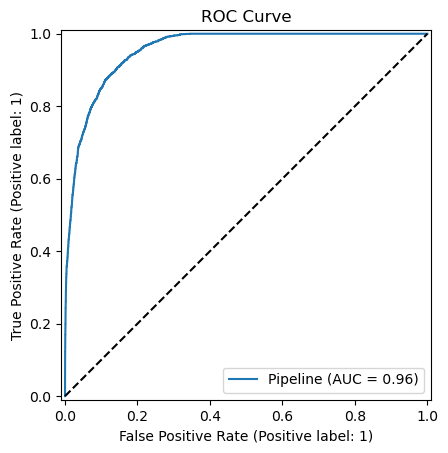

In [20]:
RocCurveDisplay.from_estimator(lr_pipe, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')

# 参数搜索
我们将使用网格搜索（GridSearchCV）来优化逻辑回归模型的超参数。

In [13]:
from sklearn.model_selection import GridSearchCV
# 定义参数网格
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'saga']
}

In [14]:
# 使用GridSearchCV进行参数搜索
grid_search = GridSearchCV(estimator=lr_pipe, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(C=0.1,
                                                           class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10],
                         'lr__penalty': ['l1', 'l2'],
                         'lr__solver': ['liblinear', 'saga']},
             scoring='roc_auc')

In [15]:
# 输出最佳参数和最佳分数
print('最佳参数:', grid_search.best_params_)
print('最佳AUC分数:', grid_search.best_score_)
best_model = grid_search.best_estimator_

最佳参数: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'saga'}
最佳AUC分数: 0.9532997767857143
